# 01. EDA — 기후 ↔ 작물 수확량 탐색적 분석

합성(USDA/NOAA/Drought Monitor 스키마 호환) 패널 데이터를 불러와 기후 변수와 수확량의 관계를 살펴본다. 데이터 생성 로직은 `src/generate_synthetic_data.py`, 병합/피처 엔지니어링은 `src/data_loader.py`에 있다.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root.parent if _root.name == 'notebooks' else _root
sys.path.insert(0, str(_root))
import pandas as pd
from src.data_loader import load_or_build_processed
from src import visualize as viz

panel, constraints = load_or_build_processed()
panel.head()

,state,year,crop,yield_bu_acre,avg_temp_f,max_temp_f,min_temp_f,precip_in,drought_index,total_cropland_acres,irrigation_acre_in_per_acre,water_use_acre_in,price_per_bu
0,IA,2000,corn,165.26,70.43,87.06,51.28,37.29,0.000,26085785,2.01,22.0,4.3
1,IA,2001,corn,165.82,68.21,86.78,49.50,33.94,0.259,26223140,1.87,22.0,4.3
2,IA,2002,corn,137.52,71.16,89.02,52.22,33.25,1.427,25830796,2.17,22.0,4.3
3,IA,2003,corn,170.40,70.62,85.00,51.66,33.83,0.526,26291243,2.11,22.0,4.3
4,IA,2004,corn,158.84,69.19,89.01,49.83,32.50,0.459,25725076,2.03,22.0,4.3


## 기본 통계

In [2]:
panel.groupby('crop')['yield_bu_acre'].describe()

,count,mean,std,min,25%,50%,75%,max
crop,,,,,,,,
corn,288.0,148.812500,34.542347,52.92,124.1275,152.985,173.5100,222.40
soybean,288.0,44.282535,8.576181,17.81,38.3925,45.295,50.4025,63.35
wheat,288.0,33.857847,9.990689,5.00,27.4800,34.320,41.3400,54.35


## 연도별 평균 수확량 추세

기술 발전(품종 개량 등)에 따른 완만한 상승 추세와 가뭄 연도(2002, 2006, 2012, 2017, 2022)의 하락이 함께 나타난다.

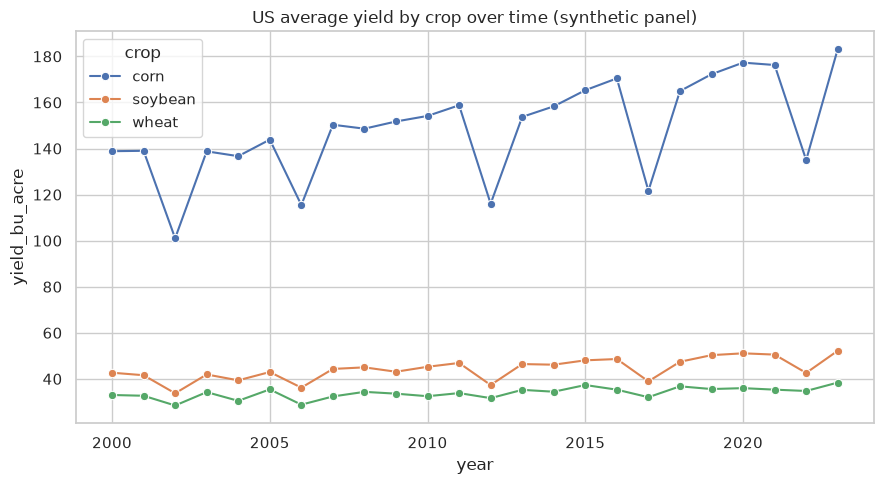

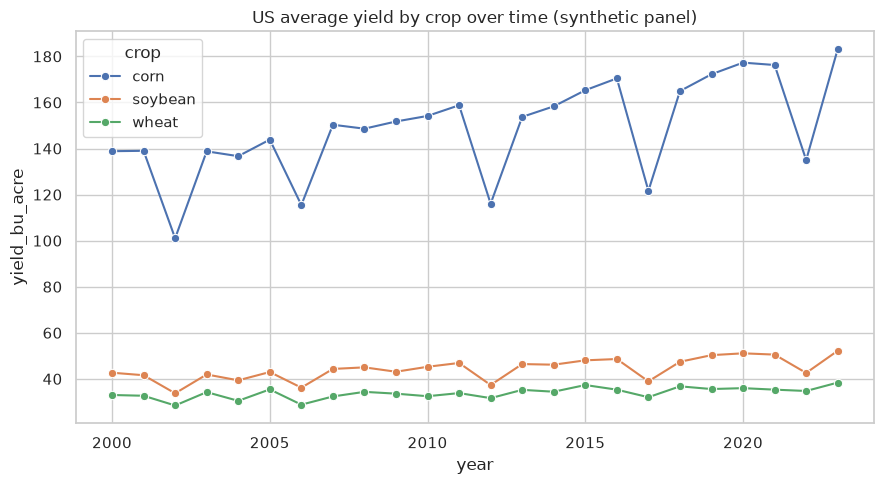

In [3]:
fig = viz.plot_yield_trend(panel)
fig

## 기후 변수 vs 수확량

각 작물은 서로 다른 최적 온도·강수·가뭄 민감도를 가지도록 시뮬레이션되어 있다 (`CROP_PARAMS` 참고).

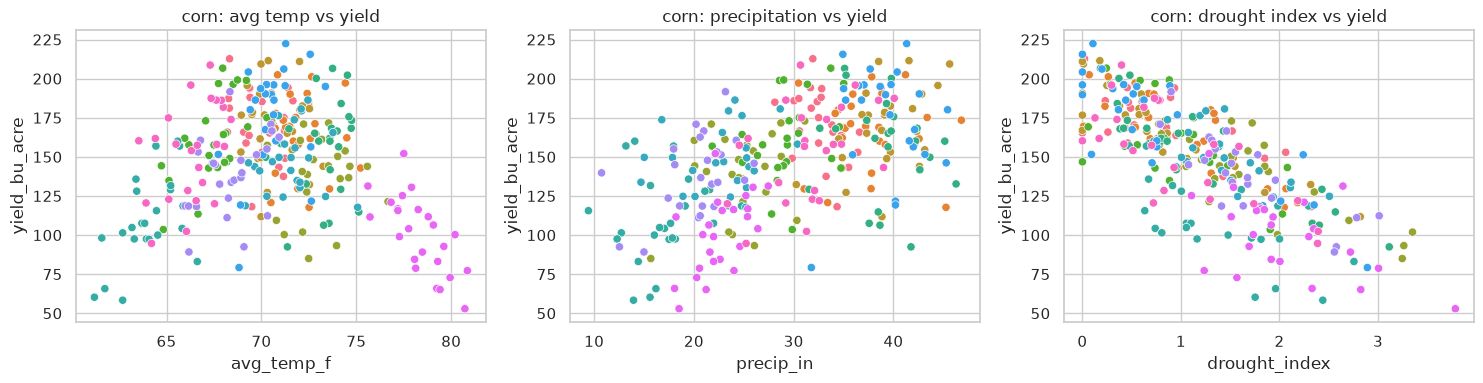

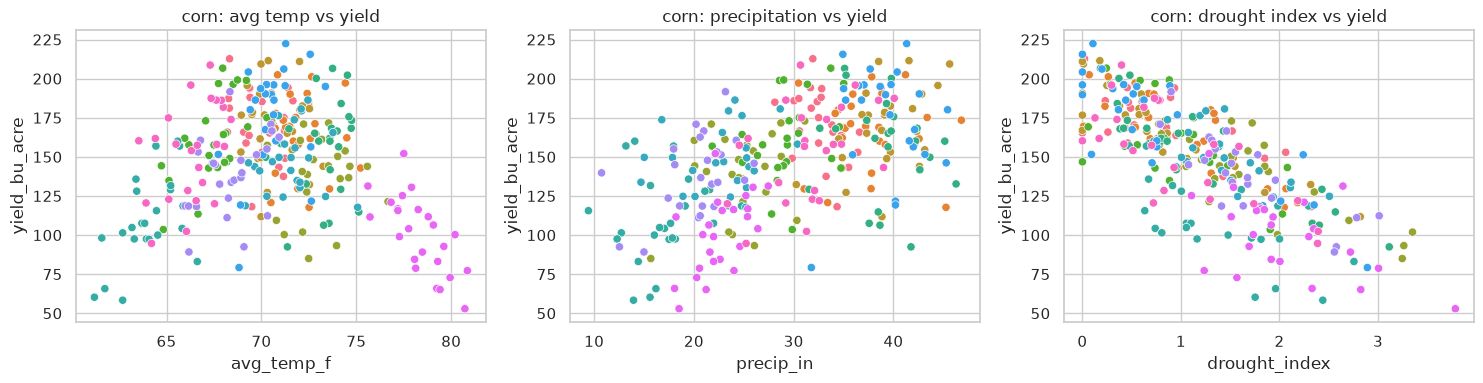

In [4]:
fig = viz.plot_climate_yield_relationship(panel, 'corn')
fig

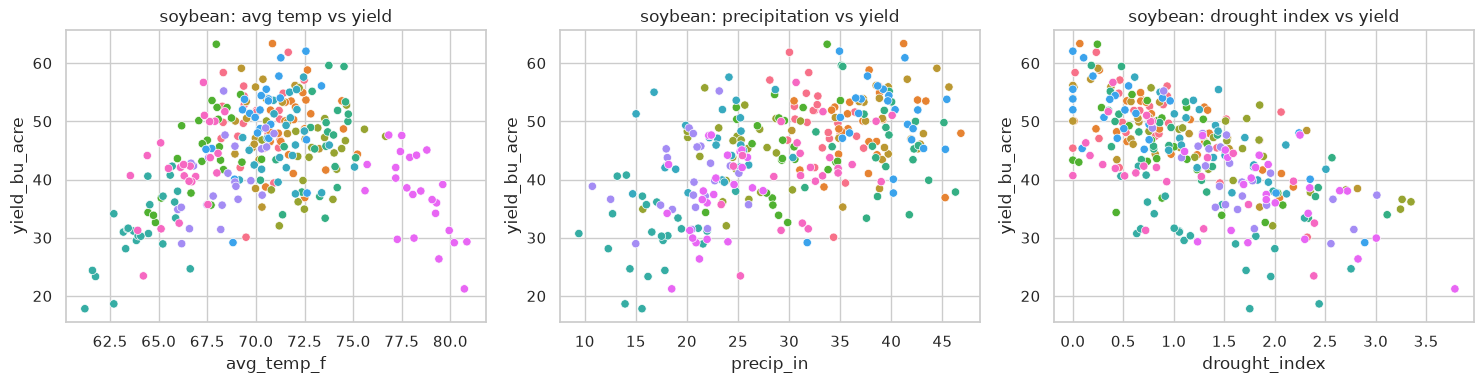

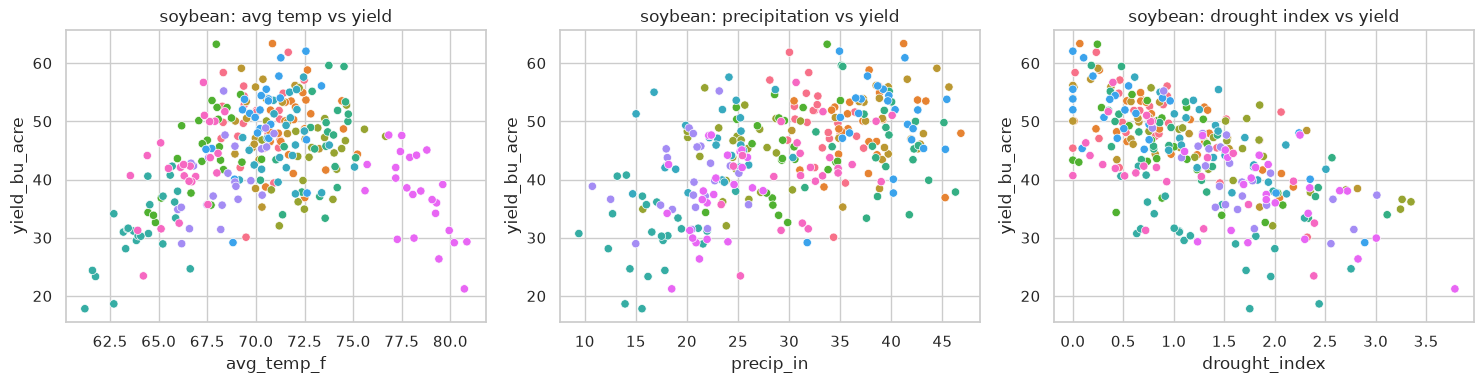

In [5]:
fig = viz.plot_climate_yield_relationship(panel, 'soybean')
fig

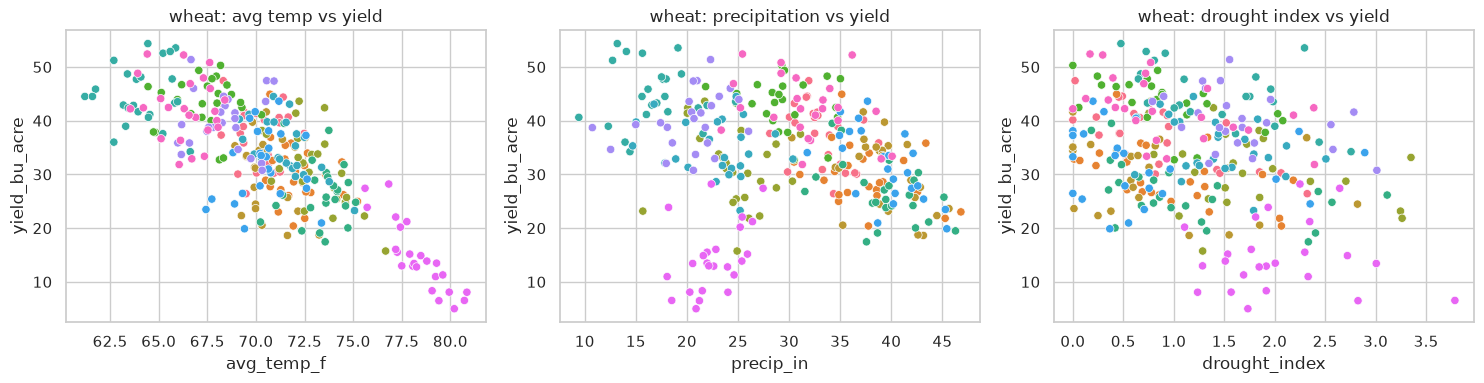

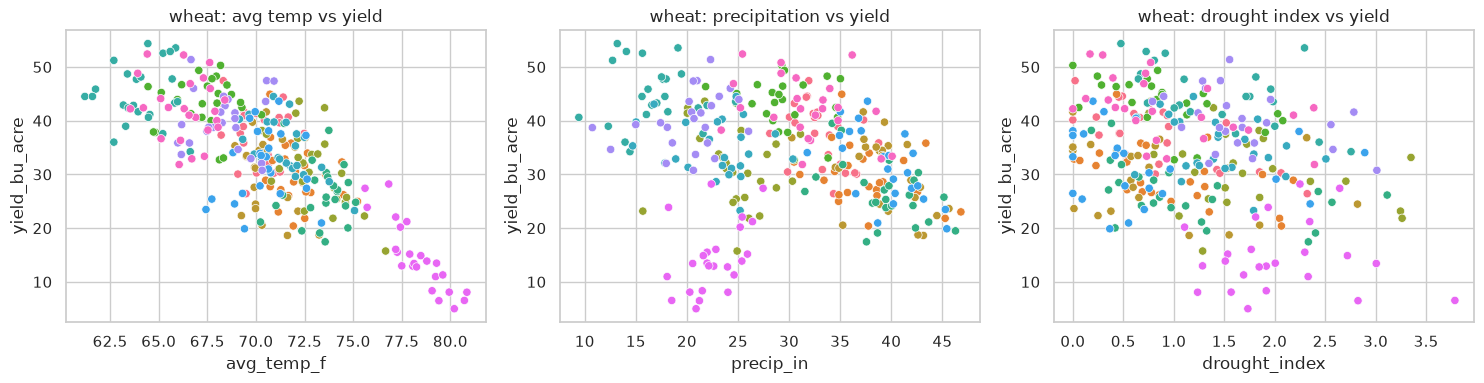

In [6]:
fig = viz.plot_climate_yield_relationship(panel, 'wheat')
fig

## 상관관계

In [7]:
from src.data_loader import feature_columns
cols = feature_columns() + ['yield_bu_acre']
panel[panel['crop']=='corn'][cols].corr()['yield_bu_acre'].sort_values()

drought_index          -0.781874
total_cropland_acres   -0.294309
avg_temp_f             -0.052731
min_temp_f             -0.048680
max_temp_f             -0.010768
precip_in               0.549110
yield_bu_acre           1.000000
Name: yield_bu_acre, dtype: float64

## 주(State)별 제약조건 (토지·물)

2단계 최적화에서 사용할 주별 가용 농경지(acre)와 관개용수 예산(acre-inch)이다.

In [8]:
constraints.sort_values('available_land_acres', ascending=False)

,state,available_land_acres,water_budget_acre_in
3,KS,15127039.73,1.639771e+08
6,ND,15046715.75,3.737604e+07
0,IA,14535295.06,2.802405e+07
10,TX,13450444.48,1.714394e+08
1,IL,13423522.86,2.733029e+07
4,MN,11653108.83,3.586827e+07
7,NE,10527508.75,1.486905e+08
9,SD,9481824.00,3.730150e+07
5,MO,7818916.05,2.706909e+07
2,IN,7311613.32,1.447699e+07
